Utilizzare il dataset CaliforniaHousing, replicare l'esercitazione pratica
- Effettuare la standarizzazione dei dati
- Trovare k tramite Elbow Method sul MSE
- Addestare un KNeighborsRegressor con il k trovato e calcolare MSE e R2
- Scegliere una feature per effettuare il plot di regressione 
- Calcolare MAE

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, r2_score

Utilizzare il dataset CaliforniaHousing, replicare l'esercitazione pratica

In [4]:
data=fetch_california_housing()
X=data.data
y=data.target

Xdf=pd.DataFrame(X,columns=data.feature_names)

display(Xdf)

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25
...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32


- Effettuare la standarizzazione dei dati

In [5]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

- Trovare k tramite Elbow Method sul MSE

In [6]:
k_range=range(1,21)
mse_values=[]
for k in k_range:
    knn_reg = KNeighborsRegressor(n_neighbors=k)
    knn_reg.fit(X_scaled, y)
    y_pred=knn_reg.predict(X_scaled)
    mse=mean_squared_error(y,y_pred)
    mse_values.append(mse)

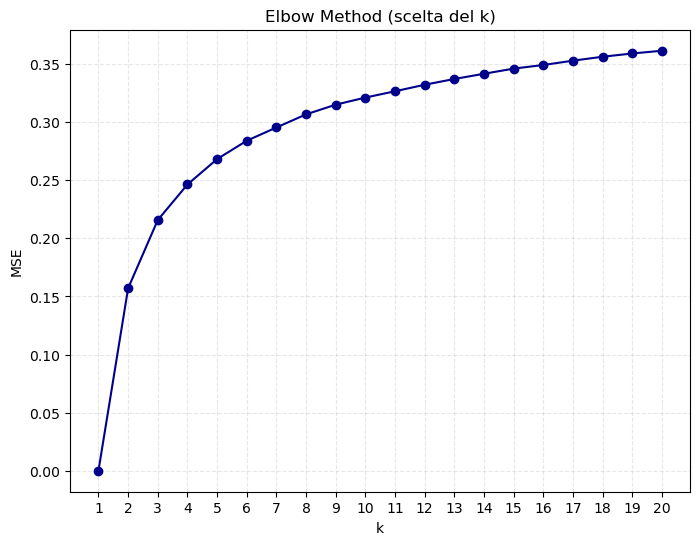

In [7]:
plt.figure(figsize=(8,6))
plt.plot(k_range, mse_values, marker="o", linestyle="-",color="darkblue")
plt.title("Elbow Method (scelta del k)")
plt.xlabel("k")
plt.ylabel("MSE")
plt.xticks(k_range)
plt.grid(linestyle="--",alpha=0.3)
plt.show()

In [12]:
best_k=3

- Addestare un KNeighborsRegressor con il k trovato e calcolare MSE e R2

In [13]:
knn_final=KNeighborsRegressor(n_neighbors=best_k)
knn_final.fit(X_scaled,y)
y_pred_final=knn_final.predict(X_scaled)

mse_final=mean_squared_error(y,y_pred_final)
r2_final=r2_score(y,y_pred_final)

print(f"K: \t{best_k}\nMSE:\t{mse_final}\nR2:\t{r2_final}")

K: 	3
MSE:	0.21576471308116868
R2:	0.8379597728543093


r2: quanto un modello spiega i dati 0=modello inutile 1=perfetto, negativo=disastro. 
    0.8380 il modello spiega il 83,80% della variabilità, il modello è ottimo, ma l'errore assolito è alto (radice quadrato di MSE= 0.46 quindi 46.000 dollari)

- Scegliere una feature per effettuare il plot di regressione 

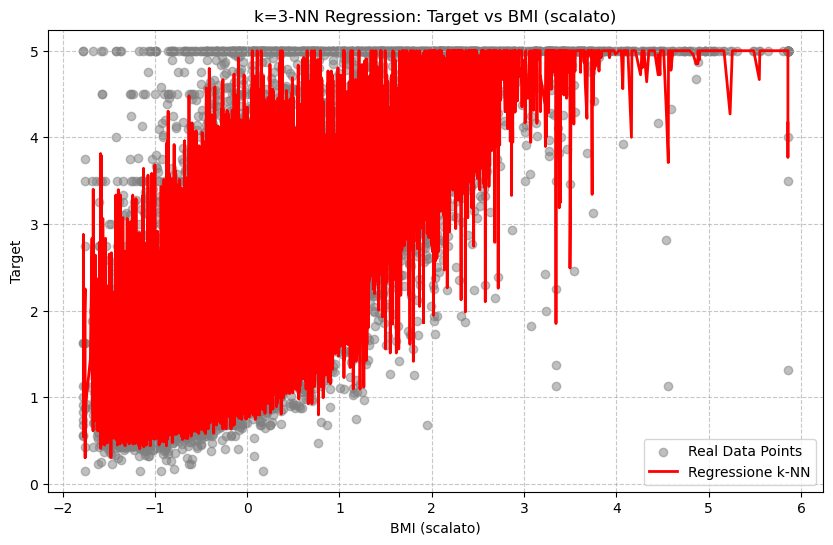

In [16]:
feature_index =  0 #MedInc (reddito medio)

sort_idx = X_scaled[:, feature_index].argsort() #prendo solo la colonna bmi e ordino per valore
X_plot = X_scaled[sort_idx, feature_index]
y_pred_plot = y_pred_final[sort_idx]

plt.figure(figsize=(10, 6))
plt.scatter(X_scaled[:, feature_index], y, color='gray', alpha=0.5, label='Real Data Points')
plt.plot(X_plot, y_pred_plot, color='red', linewidth=2, label='Regressione k-NN')
plt.title(f'k={best_k}-NN Regression: Target vs BMI (scalato)')
plt.xlabel('BMI (scalato)')
plt.ylabel('Target')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()